# 🏅 Análise Diagnóstica das Olimpíadas de Paris 2024

Este notebook cruza os dados oficiais dos Jogos Olímpicos de Paris 2024 com indicadores socioeconômicos do **World Bank** (PIB, PIB per capita, população, expectativa de vida e área territorial) para investigar uma pergunta simples: **o quanto o desempenho olímpico de um país está relacionado à sua riqueza, tamanho e nível de desenvolvimento?**

**Fontes de dados**
- [Paris 2024 Olympic Summer Games](https://www.kaggle.com/datasets/piterfm/paris-2024-olympic-summer-games) (Kaggle, via `kagglehub`) — medalhas e atletas
- [World Development Indicators](https://data.worldbank.org/) (World Bank) — PIB, PIB per capita, população, expectativa de vida, área

**Roteiro**
1. Carregar e explorar os dados de medalhas e atletas das Olimpíadas
2. Carregar os 5 indicadores do World Bank e tratar suas particularidades (linhas de metadados, anos sem dado)
3. Cruzar (join) as duas fontes por país — corrigindo divergências entre os códigos do COI (Comitê Olímpico Internacional) e o padrão ISO-3166 usado pelo World Bank
4. Explorar o cruzamento com visualizações (ranking, radar comparativo, correlação, treemap, eficiência olímpica, bolhas por continente)
5. Testar estatisticamente se altura e peso dos atletas seguem distribuição normal
6. Treinar um modelo de regressão linear para prever medalhas a partir de indicadores de riqueza, validado com train/test split

---

## 1. Dados olímpicos: medalhas e atletas

Baixamos o dataset via `kagglehub` e carregamos duas tabelas: o quadro de medalhas por país (`medals_total_df`) e o cadastro completo de atletas (`athletes_df`), que também usamos para contar quantos atletas cada país enviou.

In [25]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("piterfm/paris-2024-olympic-summer-games")

print("Path to dataset files:", path)

########

import os
import pandas as pd

medals_total_df = pd.read_csv(os.path.join(path, "medals_total.csv"))
medals_total_df.head(10)

Path to dataset files: /Users/dantas/.cache/kagglehub/datasets/piterfm/paris-2024-olympic-summer-games/versions/27


,country_code,country,country_long,Gold Medal,Silver Medal,Bronze Medal,Total
0,USA,United States,United States of America,40,44,42,126
1,CHN,China,People's Republic of China,40,27,24,91
2,JPN,Japan,Japan,20,12,13,45
3,AUS,Australia,Australia,18,19,16,53
4,FRA,France,France,16,26,22,64
5,NED,Netherlands,Netherlands,15,7,12,34
6,GBR,Great Britain,Great Britain,14,22,29,65
7,KOR,Korea,Republic of Korea,13,9,10,32
8,ITA,Italy,Italy,12,13,15,40
9,GER,Germany,Germany,12,13,8,33


In [26]:
athletes_df = pd.read_csv(os.path.join(path, "athletes.csv"))
athletes_df.head()

,code,current,name,name_short,name_tv,gender,function,country_code,country,country_long,...,family,lang,coach,reason,hero,influence,philosophy,sporting_relatives,ritual,other_sports
0,1532872,True,ALEKSANYAN Artur,ALEKSANYAN A,Artur ALEKSANYAN,Male,Athlete,ARM,Armenia,Armenia,...,"Father, Gevorg Aleksanyan","Armenian, English, Russian","Gevorg Aleksanyan (ARM), father",He followed his father and his uncle into the ...,"Footballer Zinedine Zidane (FRA), World Cup wi...","His father, Gevorg Aleksanyan","""Wrestling is my life."" (mediamax.am. 18 May 2...",NaN,NaN,NaN
1,1532873,True,AMOYAN Malkhas,AMOYAN M,Malkhas AMOYAN,Male,Athlete,ARM,Armenia,Armenia,...,NaN,Armenian,NaN,NaN,NaN,NaN,"""To become a good athlete, you first have to b...","Uncle, Roman Amoyan (wrestling), 2008 Olympic ...",NaN,NaN
2,1532874,True,GALSTYAN Slavik,GALSTYAN S,Slavik GALSTYAN,Male,Athlete,ARM,Armenia,Armenia,...,NaN,Armenian,Personal: Martin Alekhanyan (ARM).<br>National...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1532944,True,HARUTYUNYAN Arsen,HARUTYUNYAN A,Arsen HARUTYUNYAN,Male,Athlete,ARM,Armenia,Armenia,...,"Wife, Diana (married October 2022). Daughter, ...",Armenian,National: Habetnak Kurghinyan,While doing karate he noticed wrestlers traini...,"Wrestler Armen Nazaryan (ARM, BUL), two-time O...",NaN,"“Nothing is impossible, set goals in front of ...",NaN,NaN,NaN
4,1532945,True,TEVANYAN Vazgen,TEVANYAN V,Vazgen TEVANYAN,Male,Athlete,ARM,Armenia,Armenia,...,"Wife, Sona (married November 2023)","Armenian, Russian",National: Habetnak Kurghinyan (ARM),“My family did not like wrestling very much. A...,NaN,NaN,NaN,NaN,NaN,NaN


In [27]:
athletes_per_country_df = athletes_df['country_code'].value_counts()

athletes_per_country_df = athletes_per_country_df.reset_index()

athletes_per_country_df.rename(columns={"count": "athlete_count"}, inplace=True)
athletes_per_country_df.head(40)


,country_code,athlete_count
0,USA,619
1,FRA,601
2,AUS,475
3,GER,457
4,JPN,431
5,ESP,401
6,CHN,398
7,ITA,397
8,GBR,343
9,CAN,332


## 2. Indicadores socioeconômicos (World Bank)

Cada indicador do World Bank vem em um CSV separado (PIB, PIB per capita, população, expectativa de vida e área territorial). Os arquivos têm 4 linhas de metadados antes do cabeçalho de verdade, então todos são lidos com `skiprows=4`.

In [28]:
# Os arquivos CSV do World Bank possuem 4 linhas de metadados antes do cabeçalho, por isso o skiprows=4
gdp_df = pd.read_csv("data/API_NY.GDP.MKTP.CD_DS2_en_csv_v2_234.csv", skiprows=4)
gdp_per_capita_df = pd.read_csv("data/API_NY.GDP.PCAP.CD_DS2_en_csv_v2_33610.csv", skiprows=4)
population_df = pd.read_csv("data/API_SP.POP.TOTL_DS2_en_csv_v2_33112.csv", skiprows=4)
life_expectancy_df = pd.read_csv("data/API_SP.DYN.LE00.IN_DS2_en_csv_v2_408.csv", skiprows=4)
surface_area_df = pd.read_csv("data/API_AG.SRF.TOTL.K2_DS2_en_csv_v2_34852.csv", skiprows=4)

gdp_df.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,GDP (current US$),NY.GDP.MKTP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,3.092428e+09,3.276188e+09,3.347562e+09,2.461056e+09,2.889305e+09,3.326671e+09,3.746573e+09,4.167588e+09,NaN,NaN
1,Africa Eastern and Southern,AFE,GDP (current US$),NY.GDP.MKTP.CD,2.420573e+10,2.495893e+10,2.707328e+10,3.176919e+10,3.027960e+10,3.380623e+10,...,9.792406e+11,1.021972e+12,1.019354e+12,9.385461e+11,1.113060e+12,1.226461e+12,1.179122e+12,1.252564e+12,1.358694e+12,NaN
2,Afghanistan,AFG,GDP (current US$),NY.GDP.MKTP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,1.875346e+10,1.805322e+10,1.879944e+10,1.995593e+10,1.426000e+10,1.449724e+10,1.715223e+10,1.777851e+10,NaN,NaN
3,Africa Western and Central,AFW,GDP (current US$),NY.GDP.MKTP.CD,1.190481e+10,1.270772e+10,1.363059e+10,1.446891e+10,1.580356e+10,1.692088e+10,...,6.942064e+11,7.778058e+11,1.026528e+12,9.636882e+11,1.026670e+12,1.063748e+12,9.384807e+11,7.373670e+11,8.525270e+11,NaN
4,Angola,AGO,GDP (current US$),NY.GDP.MKTP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,8.562960e+10,9.050606e+10,8.119381e+10,5.851203e+10,7.828392e+10,1.282340e+11,1.060423e+11,1.030805e+11,1.221749e+11,NaN


## 3. Ranking de expectativa de vida

Como primeiro exercício com os dados do World Bank, rankeamos os países pela expectativa de vida mais recente disponível (2024) e visualizamos os 20 primeiros num gráfico de pontos (dot plot).

In [29]:
# Seleciona o ano mais recente que tenha dados disponíveis (2025 ainda está vazio)
year_columns = [col for col in life_expectancy_df.columns if col.strip().isdigit()]
year_columns_with_data = [year for year in year_columns if life_expectancy_df[year].notna().any()]
latest_year = max(year_columns_with_data, key=int)

life_expectancy_ranked_df = (
    life_expectancy_df[["Country Name", "Country Code", latest_year]]
    .dropna(subset=[latest_year])
    .rename(columns={latest_year: "life_expectancy"})
    .sort_values(by="life_expectancy", ascending=False)
    .reset_index(drop=True)
)

print(f"Ano utilizado: {latest_year}")
life_expectancy_ranked_df.head(20)

Ano utilizado: 2024


,Country Name,Country Code,life_expectancy
0,Monaco,MCO,86.497000
1,San Marino,SMR,85.817000
2,"Hong Kong SAR, China",HKG,85.392683
3,Kuwait,KWT,84.580488
4,Switzerland,CHE,84.407317
5,Liechtenstein,LIE,84.200000
6,French Polynesia,PYF,84.192000
7,Andorra,AND,84.188000
8,Sweden,SWE,84.063415
9,Japan,JPN,84.036341


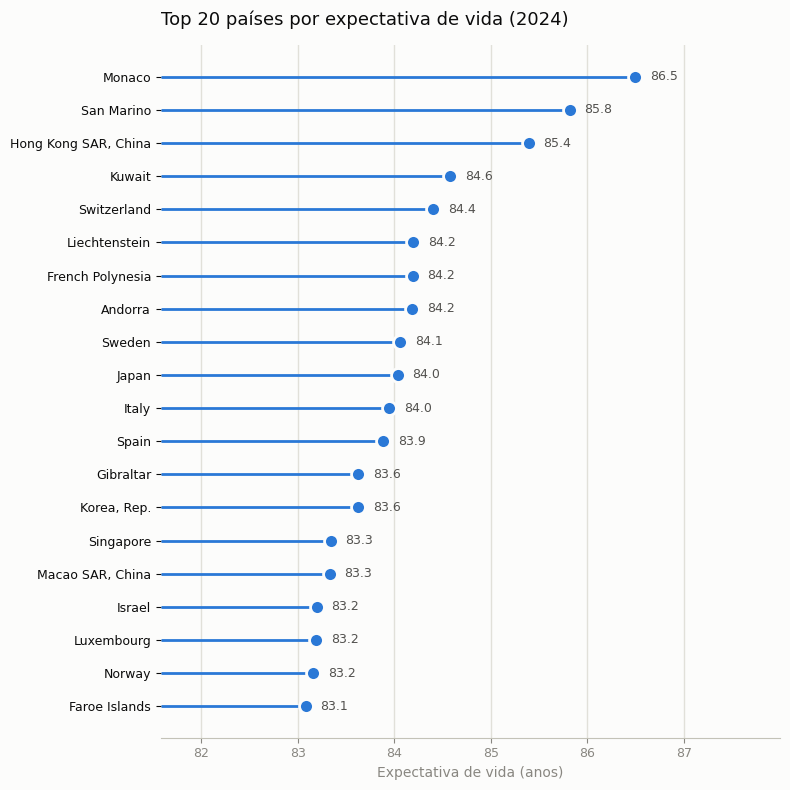

In [30]:
import matplotlib.pyplot as plt

# Mostra apenas os top N para manter o gráfico legível (a base tem centenas de países)
top_n = 20
top_life_expectancy_df = life_expectancy_ranked_df.head(top_n).sort_values(by="life_expectancy")

color_stem = "#2a78d6"
color_ring = "#fcfcfb"
color_primary = "#0b0b0b"
color_secondary = "#52514e"
color_muted = "#898781"
color_grid = "#e1e0d9"
color_baseline = "#c3c2b7"

# Como é um gráfico de pontos (não de área, como um bar chart), o eixo x pode
# ser aproximado da faixa real dos dados sem distorcer a leitura — isso evita
# que as bolinhas fiquem visualmente "empilhadas" quando os valores são próximos
min_value = top_life_expectancy_df["life_expectancy"].min()
max_value = top_life_expectancy_df["life_expectancy"].max()
xlim_left = min_value - 1.5
xlim_right = max_value + 1.5

fig, ax = plt.subplots(figsize=(8, 8), facecolor="#fcfcfb")
ax.set_facecolor("#fcfcfb")

ax.hlines(
    y=top_life_expectancy_df["Country Name"],
    xmin=xlim_left,
    xmax=top_life_expectancy_df["life_expectancy"],
    color=color_stem,
    linewidth=2,
    zorder=2,
)
ax.scatter(
    top_life_expectancy_df["life_expectancy"],
    top_life_expectancy_df["Country Name"],
    s=100,
    color=color_stem,
    edgecolor=color_ring,
    linewidth=2,
    zorder=3,
)

for value, country in zip(top_life_expectancy_df["life_expectancy"], top_life_expectancy_df["Country Name"]):
    ax.text(value + 0.15, country, f"{value:.1f}", va="center", fontsize=9, color=color_secondary)

ax.set_xlim(xlim_left, xlim_right)
ax.set_xlabel("Expectativa de vida (anos)", color=color_muted, fontsize=10)
ax.set_title(f"Top {top_n} países por expectativa de vida ({latest_year})", color=color_primary, fontsize=13, loc="left", pad=15)

for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)
ax.spines["bottom"].set_color(color_baseline)

ax.xaxis.grid(True, color=color_grid, linewidth=1)
ax.set_axisbelow(True)
ax.tick_params(axis="both", colors=color_muted, labelsize=9)
ax.tick_params(axis="y", colors=color_primary)

plt.tight_layout()
plt.show()

## 4. Preparando os dados para o cruzamento

Antes de juntar as 7 tabelas (5 do World Bank + 2 das Olimpíadas) num único dataframe por país, precisamos:
- Renomear a coluna do ano mais recente de cada indicador para um nome legível
- Selecionar só as colunas relevantes de cada um
- Resolver a maior armadilha do cruzamento: **os códigos de país não usam o mesmo padrão nas duas fontes.**

In [31]:
# Renomeando a coluna do ano mais recente de cada planilha
# obs: a área de superfície ainda não tem dados publicados para 2024, então usamos 2023 para ela

population_df.rename(columns={"2024": "populacao"}, inplace=True)
gdp_df.rename(columns={"2024": "PIB"}, inplace=True)
gdp_per_capita_df.rename(columns={"2024": "PIB_per_capita"}, inplace=True)
life_expectancy_df.rename(columns={"2024": "life_expectancy"}, inplace=True)
surface_area_df.rename(columns={"2023": "area"}, inplace=True)

In [32]:
population_df = population_df[["Country Name", "Country Code", "populacao"]]
gdp_df = gdp_df[["Country Code", "PIB"]]
gdp_per_capita_df = gdp_per_capita_df[["Country Code", "PIB_per_capita"]]
surface_area_df = surface_area_df[["Country Code", "area"]]
life_expectancy_df = life_expectancy_df[["Country Code", "life_expectancy"]]

### Códigos do COI vs. ISO-3166

O dataset das Olimpíadas identifica os países pelo código do **COI** (Comitê Olímpico Internacional), enquanto o World Bank usa o padrão **ISO-3166**. Os dois divergem para boa parte dos países — Alemanha é `GER` no COI e `DEU` no World Bank; Holanda é `NED` e `NLD` — e, sem correção, um `merge` simples por código perderia todos eles silenciosamente.

Dois casos são especialmente perigosos: os códigos do COI para **Bahrein** (`BRN`) e **Chile** (`CHI`) coincidem, por acaso, com códigos ISO reais de *outros* países (Brunei e Channel Islands). Sem tratar isso à parte, Bahrein e Chile não ficariam de fora do cruzamento — pior, eles se juntariam **silenciosamente aos dados errados**. O dicionário de tradução abaixo mapeia manualmente cerca de 80 códigos divergentes, verificados um a um contra a base do World Bank.

In [33]:
# O dataset das Olimpíadas usa códigos do COI (IOC), que divergem do ISO-3166
# usado pelo World Bank para boa parte dos países — ex.: Alemanha é "GER" no
# COI e "DEU" no World Bank; Holanda é "NED" e "NLD". Sem esse ajuste, o join
# por "Country Code" perde todos esses países (ficam de fora da tabela final).
#
# Dois casos são mais traiçoeiros: o código do COI para Bahrein ("BRN") e para
# o Chile ("CHI") coincidem, por acaso, com códigos REAIS do World Bank — só
# que de outros países (Brunei e Channel Islands, respectivamente). Sem tratar
# esses dois separadamente, Bahrein e Chile não ficariam de fora — eles se
# juntariam silenciosamente aos dados errados.
ioc_to_iso = {
    "NED": "NLD",  # Netherlands
    "GER": "DEU",  # Germany
    "IRI": "IRN",  # Iran
    "BUL": "BGR",  # Bulgaria
    "DEN": "DNK",  # Denmark
    "CRO": "HRV",  # Croatia
    "SLO": "SVN",  # Slovenia
    "PHI": "PHL",  # Philippines
    "ALG": "DZA",  # Algeria
    "INA": "IDN",  # Indonesia
    "RSA": "ZAF",  # South Africa
    "SUI": "CHE",  # Switzerland
    "POR": "PRT",  # Portugal
    "GRE": "GRC",  # Greece
    "BOT": "BWA",  # Botswana
    "GUA": "GTM",  # Guatemala
    "KOS": "XKX",  # Kosovo
    "FIJ": "FJI",  # Fiji
    "MGL": "MNG",  # Mongolia
    "GRN": "GRD",  # Grenada
    "MAS": "MYS",  # Malaysia
    "PUR": "PRI",  # Puerto Rico
    "ZAM": "ZMB",  # Zambia
    "NGR": "NGA",  # Nigeria
    "PAR": "PRY",  # Paraguay
    "LAT": "LVA",  # Latvia
    "URU": "URY",  # Uruguay
    "ANG": "AGO",  # Angola
    "GUI": "GIN",  # Guinea
    "SAM": "WSM",  # Samoa
    "BAH": "BHS",  # Bahamas
    "VIE": "VNM",  # Vietnam
    "UAE": "ARE",  # United Arab Emirates
    "MRI": "MUS",  # Mauritius
    "KUW": "KWT",  # Kuwait
    "KSA": "SAU",  # Saudi Arabia
    "PLE": "PSE",  # Palestine
    "BER": "BMU",  # Bermuda
    "ESA": "SLV",  # El Salvador
    "BUR": "BFA",  # Burkina Faso
    "GAM": "GMB",  # Gambia
    "NIG": "NER",  # Niger
    "ZIM": "ZWE",  # Zimbabwe
    "TAN": "TZA",  # Tanzania
    "HAI": "HTI",  # Haiti
    "MAD": "MDG",  # Madagascar
    "NEP": "NPL",  # Nepal
    "NCA": "NIC",  # Nicaragua
    "SRI": "LKA",  # Sri Lanka
    "GBS": "GNB",  # Guinea-Bissau
    "MON": "MCO",  # Monaco
    "CRC": "CRI",  # Costa Rica
    "VAN": "VUT",  # Vanuatu
    "LBA": "LBY",  # Libya
    "ARU": "ABW",  # Aruba
    "ISV": "VIR",  # US Virgin Islands
    "BAN": "BGD",  # Bangladesh
    "ANT": "ATG",  # Antigua and Barbuda
    "TOG": "TGO",  # Togo
    "BAR": "BRB",  # Barbados
    "HON": "HND",  # Honduras
    "SUD": "SDN",  # Sudan
    "IVB": "VGB",  # British Virgin Islands
    "TGA": "TON",  # Tonga
    "VIN": "VCT",  # St. Vincent and the Grenadines
    "OMA": "OMN",  # Oman
    "CGO": "COG",  # Congo
    "CAY": "CYM",  # Cayman Islands
    "LES": "LSO",  # Lesotho
    "GEQ": "GNQ",  # Equatorial Guinea
    "BRU": "BRN",  # Brunei
    "CHA": "TCD",  # Chad
    "SEY": "SYC",  # Seychelles
    "CAM": "KHM",  # Cambodia
    "BHU": "BTN",  # Bhutan
    "SKN": "KNA",  # St. Kitts and Nevis
    "MAW": "MWI",  # Malawi
    "MTN": "MRT",  # Mauritania
    "SOL": "SLB",  # Solomon Islands
    "MYA": "MMR",  # Myanmar
    "ASA": "ASM",  # American Samoa
    "BIZ": "BLZ",  # Belize
    "BRN": "BHR",  # Bahrain (o "BRN" do COI colide com o "BRN" do World Bank, que é Brunei)
    "CHI": "CHL",  # Chile (o "CHI" do COI colide com o "CHI" do World Bank, que é Channel Islands)
    # TPE (Chinese Taipei), AIN (Atletas Individuais Neutros), EOR (Time
    # Olímpico de Refugiados) e COK (Ilhas Cook) não têm código equivalente
    # no World Bank — não são países/territórios reconhecidos por ele — e
    # por isso continuam de fora do join mesmo depois deste ajuste.
}

medals_total_df.rename(columns={"country_code": "Country Code"}, inplace=True)
athletes_per_country_df.rename(columns={"country_code": "Country Code"}, inplace=True)

medals_total_df["Country Code"] = medals_total_df["Country Code"].replace(ioc_to_iso)
athletes_per_country_df["Country Code"] = athletes_per_country_df["Country Code"].replace(ioc_to_iso)

### Conferindo os dataframes antes do cruzamento

Uma checagem visual rápida de todos os 8 dataframes que alimentam a análise, antes de juntá-los.

In [34]:
from IPython.display import display

# Todos os dataframes usados no notebook: os 3 vindos do dataset de Olimpíadas
# (kagglehub) e os 5 vindos dos CSVs do World Bank
dataframes = {
    "medals_total_df": medals_total_df,
    "athletes_df": athletes_df,
    "athletes_per_country_df": athletes_per_country_df,
    "gdp_df": gdp_df,
    "gdp_per_capita_df": gdp_per_capita_df,
    "population_df": population_df,
    "life_expectancy_df": life_expectancy_df,
    "surface_area_df": surface_area_df,
}

for name, df in dataframes.items():
    print(f"{name} — {df.shape[0]} linhas x {df.shape[1]} colunas")
    display(df.head())
    print()

medals_total_df — 92 linhas x 7 colunas


,Country Code,country,country_long,Gold Medal,Silver Medal,Bronze Medal,Total
0,USA,United States,United States of America,40,44,42,126
1,CHN,China,People's Republic of China,40,27,24,91
2,JPN,Japan,Japan,20,12,13,45
3,AUS,Australia,Australia,18,19,16,53
4,FRA,France,France,16,26,22,64



athletes_df — 11113 linhas x 36 colunas


,code,current,name,name_short,name_tv,gender,function,country_code,country,country_long,...,family,lang,coach,reason,hero,influence,philosophy,sporting_relatives,ritual,other_sports
0,1532872,True,ALEKSANYAN Artur,ALEKSANYAN A,Artur ALEKSANYAN,Male,Athlete,ARM,Armenia,Armenia,...,"Father, Gevorg Aleksanyan","Armenian, English, Russian","Gevorg Aleksanyan (ARM), father",He followed his father and his uncle into the ...,"Footballer Zinedine Zidane (FRA), World Cup wi...","His father, Gevorg Aleksanyan","""Wrestling is my life."" (mediamax.am. 18 May 2...",NaN,NaN,NaN
1,1532873,True,AMOYAN Malkhas,AMOYAN M,Malkhas AMOYAN,Male,Athlete,ARM,Armenia,Armenia,...,NaN,Armenian,NaN,NaN,NaN,NaN,"""To become a good athlete, you first have to b...","Uncle, Roman Amoyan (wrestling), 2008 Olympic ...",NaN,NaN
2,1532874,True,GALSTYAN Slavik,GALSTYAN S,Slavik GALSTYAN,Male,Athlete,ARM,Armenia,Armenia,...,NaN,Armenian,Personal: Martin Alekhanyan (ARM).<br>National...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1532944,True,HARUTYUNYAN Arsen,HARUTYUNYAN A,Arsen HARUTYUNYAN,Male,Athlete,ARM,Armenia,Armenia,...,"Wife, Diana (married October 2022). Daughter, ...",Armenian,National: Habetnak Kurghinyan,While doing karate he noticed wrestlers traini...,"Wrestler Armen Nazaryan (ARM, BUL), two-time O...",NaN,"“Nothing is impossible, set goals in front of ...",NaN,NaN,NaN
4,1532945,True,TEVANYAN Vazgen,TEVANYAN V,Vazgen TEVANYAN,Male,Athlete,ARM,Armenia,Armenia,...,"Wife, Sona (married November 2023)","Armenian, Russian",National: Habetnak Kurghinyan (ARM),“My family did not like wrestling very much. A...,NaN,NaN,NaN,NaN,NaN,NaN



athletes_per_country_df — 206 linhas x 2 colunas


...

,Country Name,Country Code,populacao
0,Aruba,ABW,107995.0
1,Africa Eastern and Southern,AFE,769280888.0
2,Afghanistan,AFG,42647492.0
3,Africa Western and Central,AFW,520655398.0
4,Angola,AGO,37885849.0



life_expectancy_df — 265 linhas x 2 colunas


,Country Code,life_expectancy
0,ABW,76.500000
1,AFE,65.349930
2,AFG,66.289000
3,AFW,59.041538
4,AGO,64.805000



surface_area_df — 265 linhas x 2 colunas


,Country Code,area
0,ABW,180.0
1,AFE,15173741.5
2,AFG,652870.0
3,AFW,9166249.0
4,AGO,1246700.0


## 5. Tabela unificada por país

Com os códigos padronizados, cruzamos tudo num único `countries_df`: partimos da base de população do World Bank (a mais completa, com 265 países/territórios) e fazemos `left join` com o restante — assim nenhum país é descartado, só fica `NaN` onde não há dado (por exemplo, países que não disputaram as Olimpíadas).

In [35]:
# Junta todos os dataframes de país num único, usando "Country Code" como chave.
# Parte de population_df (base mais completa, com todos os países/territórios do
# World Bank) e faz left join com o restante — assim nada é descartado, só fica
# NaN onde não há dado (ex.: países que não disputaram as Olimpíadas)
countries_df = population_df.copy()

country_level_dfs = [
    gdp_df,
    gdp_per_capita_df,
    life_expectancy_df,
    surface_area_df,
    athletes_per_country_df,
    medals_total_df,
]

for df in country_level_dfs:
    countries_df = countries_df.merge(df, on="Country Code", how="left")

print(f"{countries_df.shape[0]} linhas x {countries_df.shape[1]} colunas")
countries_df.head(20)

265 linhas x 14 colunas


,Country Name,Country Code,populacao,PIB,PIB_per_capita,life_expectancy,area,athlete_count,country,country_long,Gold Medal,Silver Medal,Bronze Medal,Total
0,Aruba,ABW,107995.0,4.167588e+09,38590.565029,76.500000,180.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN
1,Africa Eastern and Southern,AFE,769280888.0,1.252564e+12,1628.227289,65.349930,15173741.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,AFG,42647492.0,1.777851e+10,416.871146,66.289000,652870.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN
3,Africa Western and Central,AFW,520655398.0,7.373670e+11,1416.228412,59.041538,9166249.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Angola,AGO,37885849.0,1.030805e+11,2720.819007,64.805000,1246700.0,25.0,NaN,NaN,NaN,NaN,NaN,NaN
5,Albania,ALB,2377128.0,2.703747e+10,11374.008578,79.776000,28750.0,8.0,Albania,Albania,0.0,0.0,2.0,2.0
6,Andorra,AND,81938.0,4.044250e+09,49357.437070,84.188000,470.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN
7,Arab World,ARB,492612632.0,3.745044e+12,7602.411157,72.721805,13166251.9,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,United Arab Emirates,ARE,10986400.0,5.523249e+11,50273.512624,83.069000,98647.9,13.0,NaN,NaN,NaN,NaN,NaN,NaN
9,Argentina,ARG,45696159.0,6.383655e+11,13969.783660,77.543000,2780400.0,143.0,Argentina,Argentina,1.0,1.0,1.0,3.0


In [36]:
# Ordena do país com mais medalhas para o com menos (quem não ganhou nenhuma
# fica no final, já que "Total" é NaN para esses casos)
countries_df = countries_df.sort_values(by="Total", ascending=False, na_position="last").reset_index(drop=True)
countries_df.head(20)

,Country Name,Country Code,populacao,PIB,PIB_per_capita,life_expectancy,area,athlete_count,country,country_long,Gold Medal,Silver Medal,Bronze Medal,Total
0,United States,USA,3.400038e+08,2.929801e+13,86169.664158,78.890244,9831510.00,619.0,United States,United States of America,40.0,44.0,42.0,126.0
1,China,CHN,1.408975e+09,1.872967e+13,13293.116227,78.017000,9562910.00,398.0,China,People's Republic of China,40.0,27.0,24.0,91.0
2,United Kingdom,GBR,6.928100e+07,3.695540e+12,53341.313109,81.386854,243610.00,343.0,Great Britain,Great Britain,14.0,22.0,29.0,65.0
3,France,FRA,6.855165e+07,3.160443e+12,46103.084086,82.980488,606410.00,601.0,France,France,16.0,26.0,22.0,64.0
4,Australia,AUS,2.719429e+07,1.757022e+12,64609.986512,83.051220,7741220.00,475.0,Australia,Australia,18.0,19.0,16.0,53.0
5,Japan,JPN,1.239754e+08,4.190008e+12,33797.101429,84.036341,377969.27,431.0,Japan,Japan,20.0,12.0,13.0,45.0
6,Italy,ITA,5.895270e+07,2.383436e+12,40429.622405,83.951220,302070.00,397.0,Italy,Italy,12.0,13.0,15.0,40.0
7,Netherlands,NLD,1.799348e+07,1.213936e+12,67465.320813,81.965854,41540.00,290.0,Netherlands,Netherlands,15.0,7.0,12.0,34.0
8,Germany,DEU,8.351659e+07,4.685593e+12,56103.732318,80.792683,357680.00,457.0,Germany,Germany,12.0,13.0,8.0,33.0
9,"Korea, Rep.",KOR,5.175106e+07,1.875388e+12,36238.639908,83.629268,100450.00,147.0,Korea,Republic of Korea,13.0,9.0,10.0,32.0


## 6. Brasil vs. Argentina: um comparativo multidimensional

Um gráfico radar comparando os dois países em 7 métricas — população, PIB, PIB per capita, expectativa de vida, área, atletas e medalhas — normalizadas como % do maior valor entre os dois em cada eixo (útil para comparar grandezas de escalas tão diferentes num único gráfico). A tabela logo abaixo mostra os valores absolutos, já que o radar normalizado por si só esconde a magnitude real das diferenças.

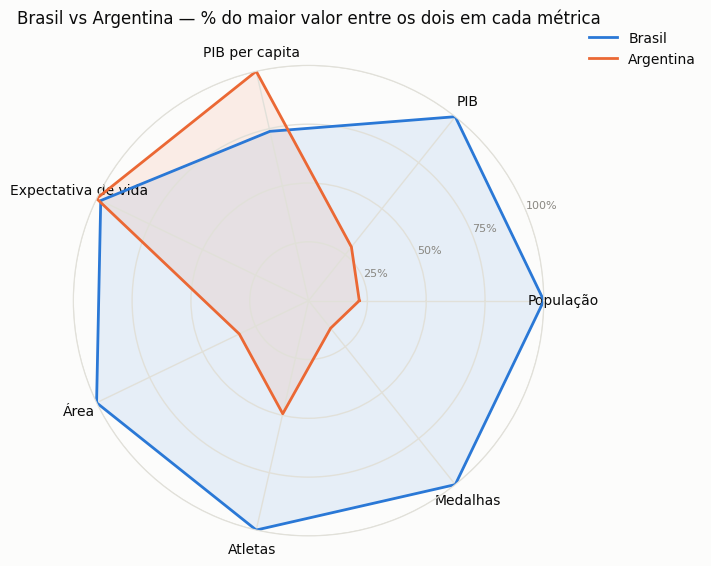

,Métrica,Brasil,Argentina
0,População,2.119986e+08,4.569616e+07
1,PIB,2.185822e+12,6.383655e+11
2,PIB per capita,1.031055e+04,1.396978e+04
3,Expectativa de vida,7.602300e+01,7.754300e+01
4,Área,8.510420e+06,2.780400e+06
5,Atletas,2.900000e+02,1.430000e+02
6,Medalhas,2.000000e+01,3.000000e+00


In [37]:
import numpy as np

# Métricas a comparar — todas já disponíveis em countries_df
metrics = {
    "populacao": "População",
    "PIB": "PIB",
    "PIB_per_capita": "PIB per capita",
    "life_expectancy": "Expectativa de vida",
    "area": "Área",
    "athlete_count": "Atletas",
    "Total": "Medalhas",
}

brazil = countries_df[countries_df["Country Code"] == "BRA"].iloc[0]
argentina = countries_df[countries_df["Country Code"] == "ARG"].iloc[0]

labels = list(metrics.values())
brazil_values = [brazil[col] for col in metrics]
argentina_values = [argentina[col] for col in metrics]

# As métricas têm escalas muito diferentes (população em milhões, PIB em
# trilhões, medalhas em unidades), então cada eixo é normalizado como % do
# maior valor entre os dois países — assim dá pra comparar todas no mesmo radar
max_values = [max(b, a) for b, a in zip(brazil_values, argentina_values)]
brazil_norm = [b / m * 100 for b, m in zip(brazil_values, max_values)]
argentina_norm = [a / m * 100 for a, m in zip(argentina_values, max_values)]

angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]
brazil_plot = brazil_norm + brazil_norm[:1]
argentina_plot = argentina_norm + argentina_norm[:1]

color_brazil = "#2a78d6"
color_argentina = "#eb6834"
color_grid = "#e1e0d9"
color_primary = "#0b0b0b"
color_muted = "#898781"

fig, ax = plt.subplots(figsize=(7.5, 7.5), subplot_kw=dict(polar=True), facecolor="#fcfcfb")
ax.set_facecolor("#fcfcfb")

ax.plot(angles, brazil_plot, color=color_brazil, linewidth=2, label="Brasil")
ax.fill(angles, brazil_plot, color=color_brazil, alpha=0.1)

ax.plot(angles, argentina_plot, color=color_argentina, linewidth=2, label="Argentina")
ax.fill(angles, argentina_plot, color=color_argentina, alpha=0.1)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, color=color_primary, fontsize=10)
ax.set_yticks([25, 50, 75, 100])
ax.set_yticklabels(["25%", "50%", "75%", "100%"], color=color_muted, fontsize=8)
ax.set_ylim(0, 100)

ax.spines["polar"].set_color(color_grid)
ax.grid(color=color_grid, linewidth=1)

ax.set_title("Brasil vs Argentina — % do maior valor entre os dois em cada métrica", color=color_primary, fontsize=12, pad=30)
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.1), frameon=False, labelcolor=color_primary)

plt.tight_layout()
plt.show()

# O radar normaliza tudo em %, então some os valores reais numa tabela — sem
# ela não dá pra saber, por exemplo, que o PIB do Brasil é ~3.4x o da Argentina
comparison_df = pd.DataFrame({
    "Métrica": labels,
    "Brasil": brazil_values,
    "Argentina": argentina_values,
})
comparison_df

## 7. A altura dos atletas segue uma distribuição normal?

Um QQ plot compara os quantis da altura observada com os de uma distribuição normal teórica — se os pontos seguem a linha de referência, a distribuição é (aproximadamente) normal. O resultado (r ≈ 0,997) mostra um ajuste bastante forte, com um leve desvio nas extremidades: atletas muito baixos ficam um pouco acima da linha, indicando uma cauda esquerda mais pesada do que uma normal perfeita — plausível, já que esportes como ginástica concentram atletas mais baixos.

5078 atletas com altura registrada (de 11113 no total)


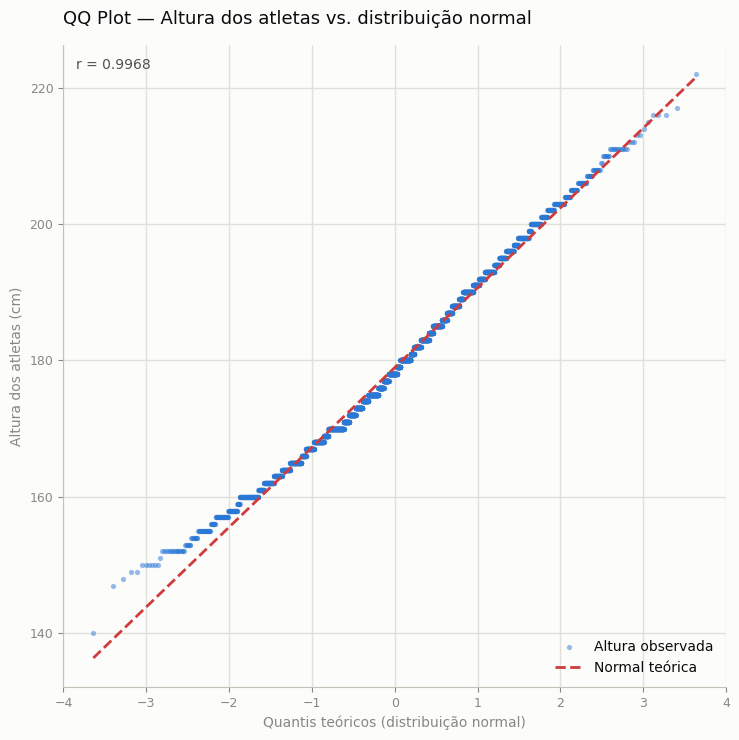

In [38]:
from scipy import stats

# altura == 0 significa dado ausente no dataset, não altura zero — precisa filtrar
heights = athletes_df.loc[athletes_df["height"] > 0, "height"]
print(f"{len(heights)} atletas com altura registrada (de {len(athletes_df)} no total)")

# probplot calcula os quantis teóricos da normal e ajusta uma reta de referência
# (mínimos quadrados) — se os pontos seguirem a reta, a distribuição é normal
(osm, osr), (slope, intercept, r) = stats.probplot(heights, dist="norm")

color_sample = "#2a78d6"
color_reference = "#d03b3b"
color_primary = "#0b0b0b"
color_secondary = "#52514e"
color_muted = "#898781"
color_grid = "#e1e0d9"
color_baseline = "#c3c2b7"

fig, ax = plt.subplots(figsize=(7.5, 7.5), facecolor="#fcfcfb")
ax.set_facecolor("#fcfcfb")

# alpha baixo porque são +5000 pontos — em vez de anel de contorno em cada
# marcador (inviável nessa densidade), a transparência mostra onde eles se acumulam
ax.scatter(osm, osr, s=14, color=color_sample, alpha=0.5, linewidths=0, label="Altura observada", zorder=2)

line_x = [osm.min(), osm.max()]
line_y = [slope * x + intercept for x in line_x]
ax.plot(line_x, line_y, color=color_reference, linewidth=2, linestyle="--", label="Normal teórica", zorder=3)

ax.set_xlabel("Quantis teóricos (distribuição normal)", color=color_muted, fontsize=10)
ax.set_ylabel("Altura dos atletas (cm)", color=color_muted, fontsize=10)
ax.set_title("QQ Plot — Altura dos atletas vs. distribuição normal", color=color_primary, fontsize=13, loc="left", pad=15)

ax.text(
    0.02, 0.98, f"r = {r:.4f}",
    transform=ax.transAxes, ha="left", va="top",
    fontsize=10, color=color_secondary,
)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
ax.spines["left"].set_color(color_baseline)
ax.spines["bottom"].set_color(color_baseline)

ax.grid(True, color=color_grid, linewidth=1)
ax.set_axisbelow(True)
ax.tick_params(axis="both", colors=color_muted, labelsize=9)

ax.legend(loc="lower right", frameon=False, labelcolor=color_primary)

plt.tight_layout()
plt.show()

## 8. Será que riqueza prevê medalhas? Um modelo preditivo

Treinamos uma regressão linear para prever o total de medalhas de um país a partir unicamente de indicadores de **riqueza** — PIB, PIB per capita e população —, com as features padronizadas por z-score (`StandardScaler`) antes do ajuste, já que estão em escalas completamente diferentes entre si.

**Resultado: R² = 0,7394.** O PIB total é, disparado, o preditor mais forte (coeficiente padronizado ≈ 12,9); PIB per capita e população contribuem bem menos. Ou seja: o **tamanho da economia** de um país explica boa parte do seu desempenho olímpico — o que faz sentido, já que mais recursos financeiros tendem a significar mais investimento em esporte de alto rendimento.

A tabela final compara, país a país, quantas medalhas o modelo previu contra quantas cada um realmente ganhou. Alguns países (Reino Unido, França, Austrália, Nova Zelândia) ganharam muito mais medalhas do que sua riqueza sozinha sugeriria — sinal de que outros fatores, como investimento esportivo dedicado e cultura olímpica, pesam mais do que dinheiro puro.

In [39]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Só faz sentido prever medalhas para quem de fato competiu — countries_df tem
# todo país/território do World Bank, e a maioria nunca disputou as Olimpíadas
model_df = countries_df[countries_df["athlete_count"].notna()].copy()

# Entre quem competiu, "Total" NaN significa "não ganhou nenhuma medalha" (um
# zero de verdade), não dado ausente — medals_total_df só lista quem pontuou
model_df["Total"] = model_df["Total"].fillna(0)

# Riqueza (PIB e PIB per capita) + população — sem expectativa de vida, área
# ou atletas
feature_cols = ["PIB", "PIB_per_capita", "populacao"]
target_col = "Total"

# Algumas poucas nações pequenas não têm PIB no World Bank — essas linhas
# ficam de fora do modelo
before = len(model_df)
model_df = model_df.dropna(subset=feature_cols)
print(f"{len(model_df)} países usados no modelo (de {before} participantes; {before - len(model_df)} descartados por dado faltante)")

X = model_df[feature_cols]
y = model_df[target_col]

# Padronização z-score: PIB (trilhões), PIB per capita (dezenas de milhares) e
# população (centenas de milhões) estão em escalas bem diferentes — sem isso
# os coeficientes não seriam comparáveis entre si
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = LinearRegression()
model.fit(X_scaled, y)

y_pred = model.predict(X_scaled)
r2 = r2_score(y, y_pred)

print(f"\nR² = {r2:.4f}")

# Com as features padronizadas, o tamanho do coeficiente já indica a
# importância relativa de cada uma para prever medalhas
coef_df = pd.Series(model.coef_, index=feature_cols, name="coeficiente_padronizado")
coef_df = coef_df.reindex(coef_df.abs().sort_values(ascending=False).index)
coef_df

191 países usados no modelo (de 202 participantes; 11 descartados por dado faltante)

R² = 0.7394


PIB               12.935422
PIB_per_capita     1.043522
populacao         -0.959928
Name: coeficiente_padronizado, dtype: float64

In [40]:
results_df = pd.DataFrame({
    "Medalhas reais": y.values,
    "Previsão do modelo": y_pred.round(2),
    "Diferença": (y.values - y_pred).round(2),
}, index=model_df["Country Name"].values)

results_df = results_df.sort_values(by="Medalhas reais", ascending=False)
results_df

,Medalhas reais,Previsão do modelo,Diferença
United States,126.0,149.48,-23.48
China,91.0,87.52,3.48
United Kingdom,65.0,21.76,43.24
France,64.0,18.87,45.13
Australia,53.0,12.63,40.37
...,...,...,...
Guinea,0.0,2.17,-2.17
Ghana,0.0,2.36,-2.36
Gabon,0.0,2.42,-2.42
"Micronesia, Fed. Sts.",0.0,2.22,-2.22


## 9. Análises complementares

Um conjunto de análises adicionais para aprofundar o cruzamento entre desempenho olímpico e indicadores socioeconômicos.

In [41]:
import sys
import subprocess

# squarify (treemap) e pycountry_convert (código de país -> continente) não são
# bibliotecas padrão — instala só se ainda não estiverem disponíveis
for pkg in ["squarify", "pycountry_convert"]:
    try:
        __import__(pkg)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])

### Correlação entre métricas

Uma matriz de correlação entre medalhas, atletas, população, PIB, PIB per capita, área e expectativa de vida. `athlete_count` (0,88) e `PIB` (0,85) são os mais correlacionados com o total de medalhas — reforçando o achado do modelo de regressão: tamanho da delegação e da economia pesam mais do que riqueza per capita (correlação de apenas 0,20) ou área territorial.

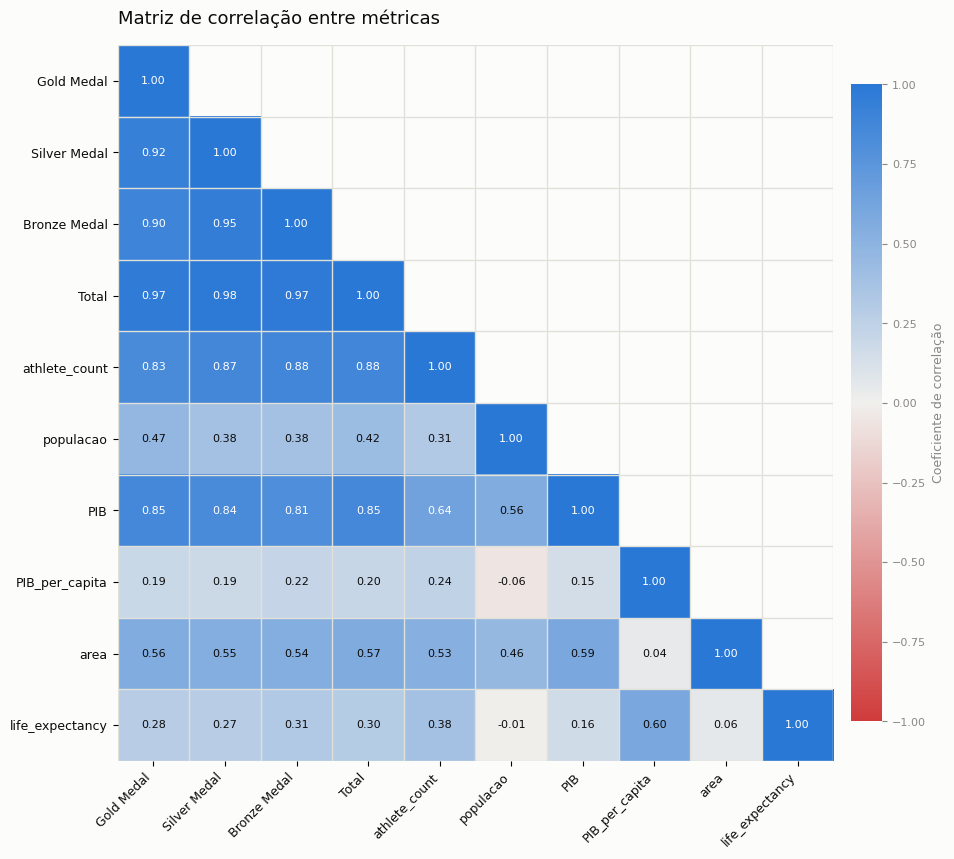

In [42]:
import matplotlib.colors as mcolors

# Correlação entre medalhas e as demais métricas — só entre quem competiu, com
# medalhas NaN viradas em 0 (mesmo raciocínio das células anteriores)
corr_df = countries_df[countries_df["athlete_count"].notna()].copy()
for col in ["Gold Medal", "Silver Medal", "Bronze Medal", "Total"]:
    corr_df[col] = corr_df[col].fillna(0)

correlation_columns = [
    "Gold Medal", "Silver Medal", "Bronze Medal", "Total",
    "athlete_count", "populacao", "PIB", "PIB_per_capita", "area", "life_expectancy",
]
corr_matrix = corr_df[correlation_columns].corr()

# Colormap divergente (par azul-vermelho da paleta), com cinza neutro no zero
cmap = mcolors.LinearSegmentedColormap.from_list("diverging_blue_red", ["#d03b3b", "#f0efec", "#2a78d6"])

# Máscara no triângulo superior — é redundante com o inferior (mesma info espelhada)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
masked = np.ma.array(corr_matrix.values, mask=mask)

color_primary = "#0b0b0b"
color_muted = "#898781"
color_grid = "#e1e0d9"

fig, ax = plt.subplots(figsize=(10, 9), facecolor="#fcfcfb")
ax.set_facecolor("#fcfcfb")

im = ax.imshow(masked, cmap=cmap, vmin=-1, vmax=1)

n = len(correlation_columns)
for i in range(n):
    for j in range(n):
        if not mask[i, j]:
            value = corr_matrix.values[i, j]
            text_color = "#ffffff" if abs(value) > 0.6 else color_primary
            ax.text(j, i, f"{value:.2f}", ha="center", va="center", fontsize=8, color=text_color)

ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(correlation_columns, rotation=45, ha="right", color=color_primary, fontsize=9)
ax.set_yticklabels(correlation_columns, color=color_primary, fontsize=9)

for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_xticks(np.arange(-0.5, n, 1), minor=True)
ax.set_yticks(np.arange(-0.5, n, 1), minor=True)
ax.grid(which="minor", color=color_grid, linewidth=1)
ax.tick_params(which="minor", size=0)

cbar = fig.colorbar(im, ax=ax, shrink=0.8, pad=0.02)
cbar.set_label("Coeficiente de correlação", color=color_muted, fontsize=9)
cbar.ax.tick_params(colors=color_muted, labelsize=8)
cbar.outline.set_visible(False)

ax.set_title("Matriz de correlação entre métricas", color=color_primary, fontsize=13, loc="left", pad=15)

plt.tight_layout()
plt.show()

### Quem tem mais gente, quem tem mais medalha

Um treemap com o tamanho de cada bloco representando a população do país, e a cor destacando quem ficou acima ou abaixo da média de medalhas entre os participantes. Fica visualmente claro que ter muita população não é garantia de medalha — Nigéria, Indonésia e Paquistão, entre os países mais populosos do mundo, ficam abaixo da média. A Índia é o caso mais interessante: supera a média em medalhas absolutas (6), mas precisa de 242 milhões de habitantes para cada uma — de longe a pior eficiência da base (ver seção seguinte).

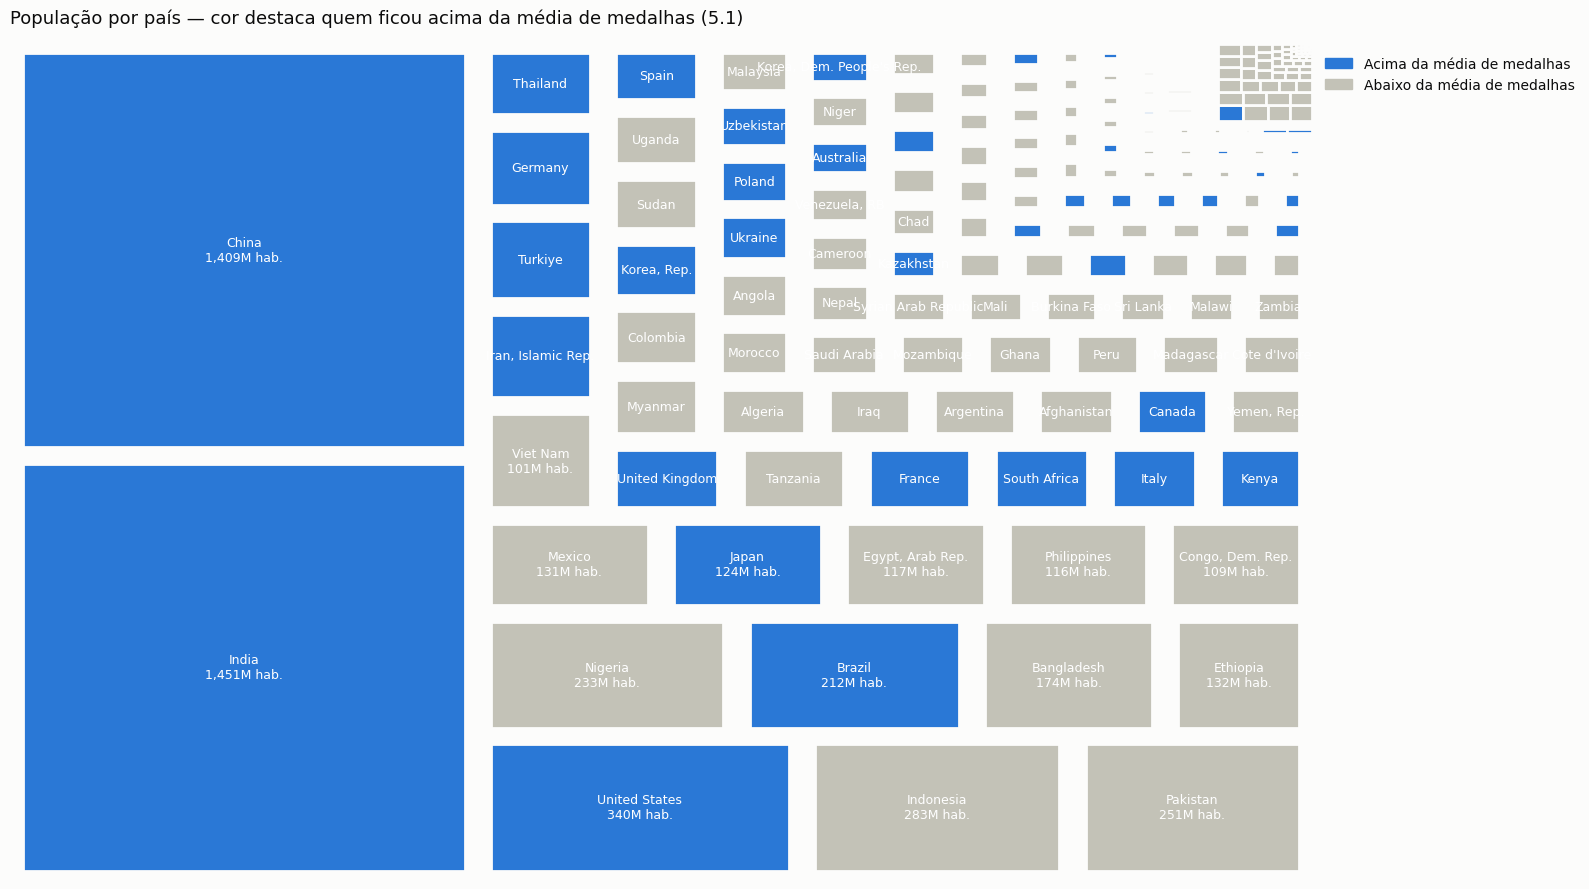

In [43]:
import squarify

# Treemap: cada bloco é um país, tamanho = população, cor destaca quem ficou
# acima da média de medalhas entre os participantes
treemap_df = countries_df[countries_df["athlete_count"].notna()].copy()
treemap_df["Total"] = treemap_df["Total"].fillna(0)

average_medals = treemap_df["Total"].mean()
treemap_df["medal_category"] = np.where(treemap_df["Total"] >= average_medals, "Acima da média", "Abaixo da média")

treemap_df = treemap_df.dropna(subset=["populacao"])
treemap_df = treemap_df[treemap_df["populacao"] > 0].sort_values(by="populacao", ascending=False)

color_above = "#2a78d6"
color_below = "#c3c2b7"
color_primary = "#0b0b0b"

# Só rotula blocos grandes o bastante pra caber o texto — bloco pequeno com
# label sempre vaza ou fica ilegível
large_threshold = 100_000_000
medium_threshold = 20_000_000

def make_label(row):
    if row["populacao"] >= large_threshold:
        return f"{row['Country Name']}\n{row['populacao']/1e6:,.0f}M hab."
    elif row["populacao"] >= medium_threshold:
        return row["Country Name"]
    return ""

labels = treemap_df.apply(make_label, axis=1).values
colors = treemap_df["medal_category"].map({"Acima da média": color_above, "Abaixo da média": color_below}).values

fig, ax = plt.subplots(figsize=(16, 9), facecolor="#fcfcfb")
ax.set_facecolor("#fcfcfb")

squarify.plot(
    sizes=treemap_df["populacao"].values,
    label=labels,
    color=colors,
    alpha=1.0,
    ax=ax,
    pad=True,
    bar_kwargs={"linewidth": 2, "edgecolor": "#fcfcfb"},
    text_kwargs={"fontsize": 9, "color": "#ffffff"},
)

ax.set_title(
    f"População por país — cor destaca quem ficou acima da média de medalhas ({average_medals:.1f})",
    color=color_primary, fontsize=13, loc="left", pad=15,
)
ax.axis("off")

legend_handles = [
    plt.Rectangle((0, 0), 1, 1, color=color_above, label="Acima da média de medalhas"),
    plt.Rectangle((0, 0), 1, 1, color=color_below, label="Abaixo da média de medalhas"),
]
ax.legend(handles=legend_handles, loc="upper left", bbox_to_anchor=(1.0, 1.0), frameon=False, labelcolor=color_primary)

plt.tight_layout()
plt.show()

### Eficiência olímpica: fazendo mais com menos

Duas métricas de eficiência — habitantes por medalha e atletas por medalha — entre os países que ganharam pelo menos 5 medalhas. Índia é disparadamente o país "menos eficiente" em população por medalha; no outro extremo, Nova Zelândia, Jamaica e Hungria conseguem muitas medalhas com poucos habitantes.

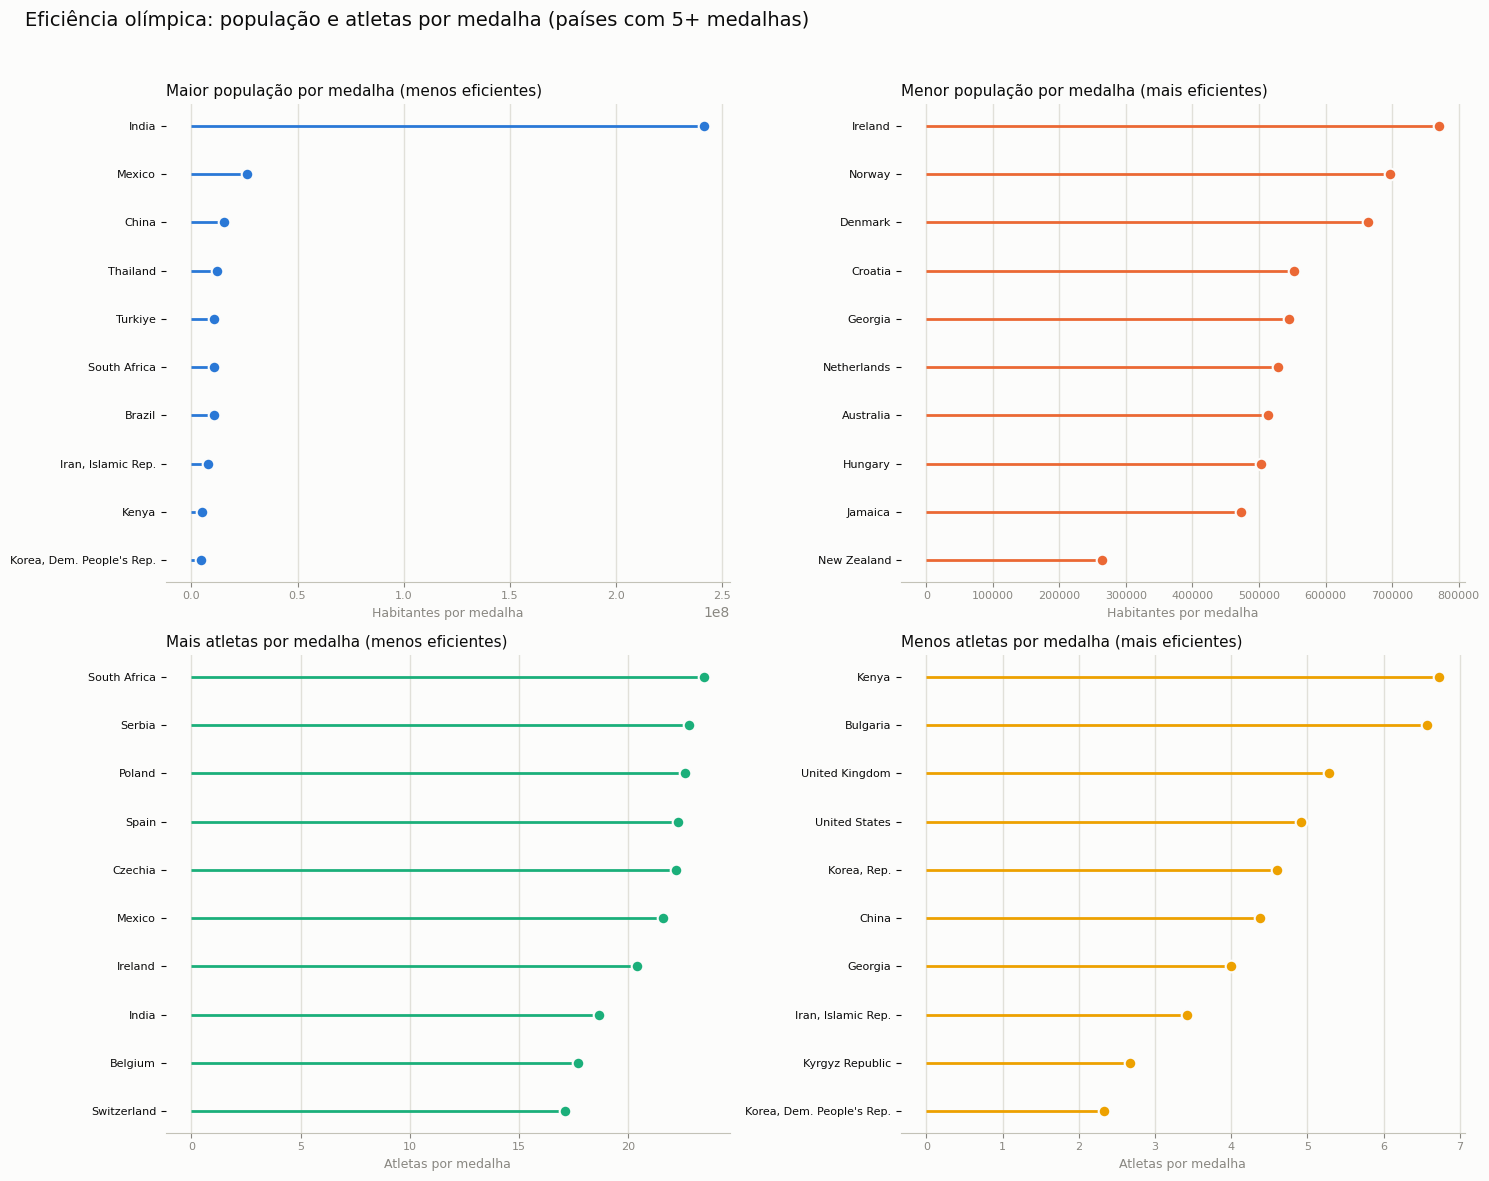

In [44]:
# Métricas de eficiência: quantos habitantes / atletas "custou" cada medalha
eff_df = countries_df[countries_df["athlete_count"].notna()].copy()
eff_df["Total"] = eff_df["Total"].fillna(0)

# Evita divisão por zero: sem nenhuma medalha, a métrica de eficiência não é definida
total_for_calc = eff_df["Total"].replace(0, np.nan)
eff_df["population_per_medal"] = eff_df["populacao"] / total_for_calc
eff_df["athlete_per_medal"] = eff_df["athlete_count"] / total_for_calc

# Só faz sentido comparar eficiência entre quem ganhou um número razoável de medalhas
eff_df = eff_df[eff_df["Total"] >= 5]

color_primary = "#0b0b0b"
color_muted = "#898781"
color_grid = "#e1e0d9"
color_baseline = "#c3c2b7"
color_ring = "#fcfcfb"
panel_colors = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]

def lollipop(ax, data, value_col, color, title, xlabel):
    data = data.sort_values(by=value_col)
    ax.hlines(y=data["Country Name"], xmin=0, xmax=data[value_col], color=color, linewidth=2, zorder=2)
    ax.scatter(data[value_col], data["Country Name"], s=70, color=color, edgecolor=color_ring, linewidth=1.5, zorder=3)
    ax.set_title(title, color=color_primary, fontsize=11, loc="left")
    ax.set_xlabel(xlabel, color=color_muted, fontsize=9)
    for spine in ["top", "right", "left"]:
        ax.spines[spine].set_visible(False)
    ax.spines["bottom"].set_color(color_baseline)
    ax.xaxis.grid(True, color=color_grid, linewidth=1)
    ax.set_axisbelow(True)
    ax.tick_params(axis="both", colors=color_muted, labelsize=8)
    ax.tick_params(axis="y", colors=color_primary)

fig, axes = plt.subplots(2, 2, figsize=(15, 12), facecolor="#fcfcfb")
fig.suptitle("Eficiência olímpica: população e atletas por medalha (países com 5+ medalhas)", color=color_primary, fontsize=14, x=0.02, ha="left")
for ax in axes.flat:
    ax.set_facecolor("#fcfcfb")

lollipop(
    axes[0, 0], eff_df.sort_values(by="population_per_medal", ascending=False).head(10),
    "population_per_medal", panel_colors[0],
    "Maior população por medalha (menos eficientes)", "Habitantes por medalha",
)
lollipop(
    axes[0, 1], eff_df.sort_values(by="population_per_medal", ascending=True).head(10),
    "population_per_medal", panel_colors[1],
    "Menor população por medalha (mais eficientes)", "Habitantes por medalha",
)
lollipop(
    axes[1, 0], eff_df.sort_values(by="athlete_per_medal", ascending=False).head(10),
    "athlete_per_medal", panel_colors[2],
    "Mais atletas por medalha (menos eficientes)", "Atletas por medalha",
)
lollipop(
    axes[1, 1], eff_df.sort_values(by="athlete_per_medal", ascending=True).head(10),
    "athlete_per_medal", panel_colors[3],
    "Menos atletas por medalha (mais eficientes)", "Atletas por medalha",
)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

### Onde riqueza, saúde e medalhas se encontram

Um bubble chart relacionando PIB per capita (eixo x, escala log) e expectativa de vida (eixo y) — dois indicadores classicamente correlacionados no desenvolvimento humano —, com o tamanho da bolha representando o total de medalhas e a cor indicando o continente (mapeado a partir do código do país com `pycountry_convert`). O padrão é nítido: os países no canto superior direito (ricos e com alta expectativa de vida) concentram as maiores bolhas — ou seja, mais medalhas.

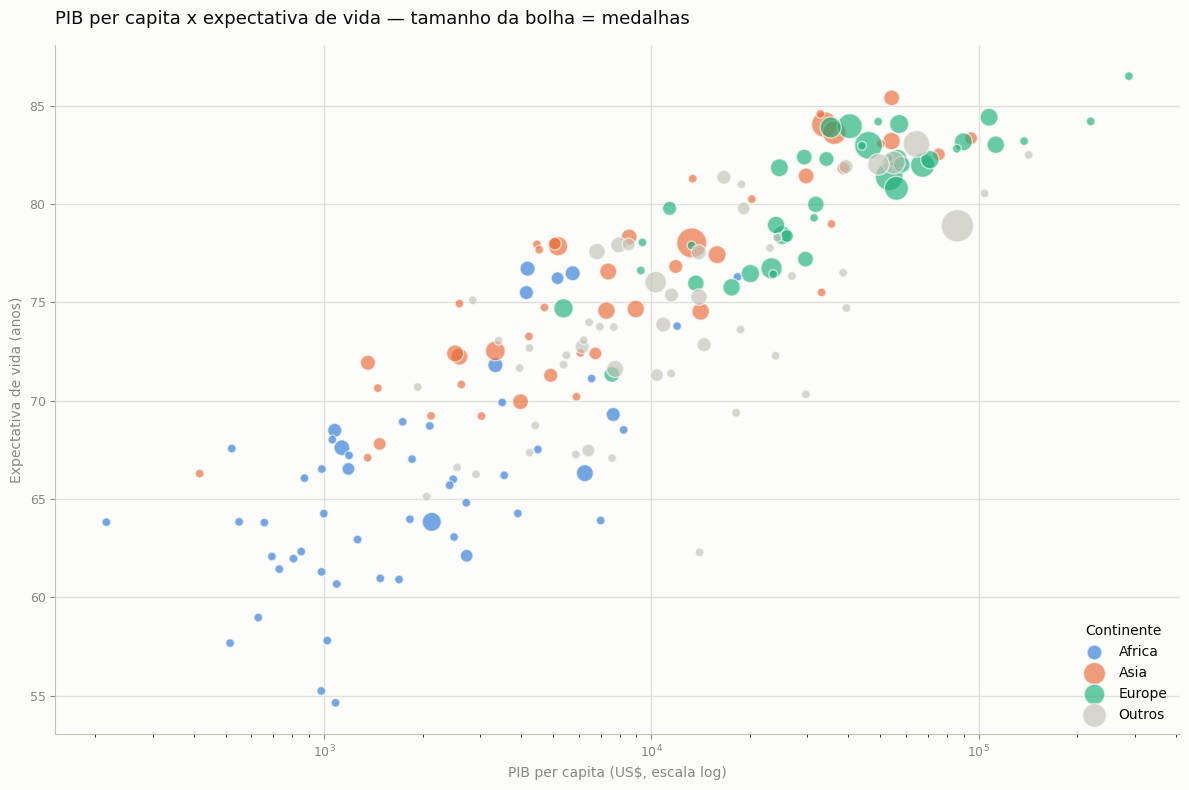

In [45]:
import pycountry_convert as pc

def country_code_to_continent(country_code):
    try:
        alpha2 = pc.country_alpha3_to_country_alpha2(country_code)
        continent_code = pc.country_alpha2_to_continent_code(alpha2)
        return pc.convert_continent_code_to_continent_name(continent_code)
    except (KeyError, TypeError):
        return "Desconhecido"

continent_df = countries_df[countries_df["athlete_count"].notna()].copy()
continent_df["Total"] = continent_df["Total"].fillna(0)
continent_df["continent"] = continent_df["Country Code"].apply(country_code_to_continent)

plot_data = continent_df.dropna(subset=["PIB_per_capita", "life_expectancy"]).copy()
plot_data = plot_data[plot_data["continent"] != "Desconhecido"]

# Bubble/scatter com cor categórica só é seguro (ver skill de dataviz) para até
# 3 cores comparadas par-a-par; os 3 continentes mais frequentes viram cor "de
# verdade" e o resto entra como "Outros" em cinza neutro (destaque, não ausência)
top_continents = plot_data["continent"].value_counts().head(3).index.tolist()
plot_data["continent_group"] = np.where(plot_data["continent"].isin(top_continents), plot_data["continent"], "Outros")

color_map = {
    top_continents[0]: "#2a78d6",
    top_continents[1]: "#eb6834",
    top_continents[2]: "#1baf7a",
    "Outros": "#c3c2b7",
}

color_primary = "#0b0b0b"
color_muted = "#898781"
color_grid = "#e1e0d9"
color_ring = "#fcfcfb"

size_floor = 40

fig, ax = plt.subplots(figsize=(12, 8), facecolor="#fcfcfb")
ax.set_facecolor("#fcfcfb")

for group in color_map:
    subset = plot_data[plot_data["continent_group"] == group]
    subset_sizes = size_floor + np.sqrt(subset["Total"].clip(lower=0)) * 45
    ax.scatter(
        subset["PIB_per_capita"], subset["life_expectancy"],
        s=subset_sizes, color=color_map[group], alpha=0.65,
        edgecolor=color_ring, linewidth=1, label=group, zorder=3,
    )

ax.set_xscale("log")
ax.set_xlabel("PIB per capita (US$, escala log)", color=color_muted, fontsize=10)
ax.set_ylabel("Expectativa de vida (anos)", color=color_muted, fontsize=10)
ax.set_title("PIB per capita x expectativa de vida — tamanho da bolha = medalhas", color=color_primary, fontsize=13, loc="left", pad=15)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
ax.spines["left"].set_color("#c3c2b7")
ax.spines["bottom"].set_color("#c3c2b7")
ax.grid(True, color=color_grid, linewidth=1, which="major")
ax.set_axisbelow(True)
ax.tick_params(axis="both", colors=color_muted, labelsize=9)

legend = ax.legend(loc="lower right", frameon=False, labelcolor=color_primary, title="Continente")
legend.get_title().set_color(color_primary)

plt.tight_layout()
plt.show()

### Corpo dos atletas: altura e peso por gênero

Repetimos o teste de normalidade (QQ plot) separando por gênero, tanto para altura quanto para peso. Separar por gênero deixa o ajuste à normal ainda mais forte para os homens (r ≈ 0,999) e também forte para as mulheres (r ≈ 0,995) — o leve desvio visto no QQ plot combinado da Seção 7 era, em parte, efeito de misturar duas distribuições com médias diferentes.

Vale notar que peso é uma coluna bem mais esparsa que altura no dataset: só cerca de 3% dos atletas têm peso registrado, contra 46% para altura.

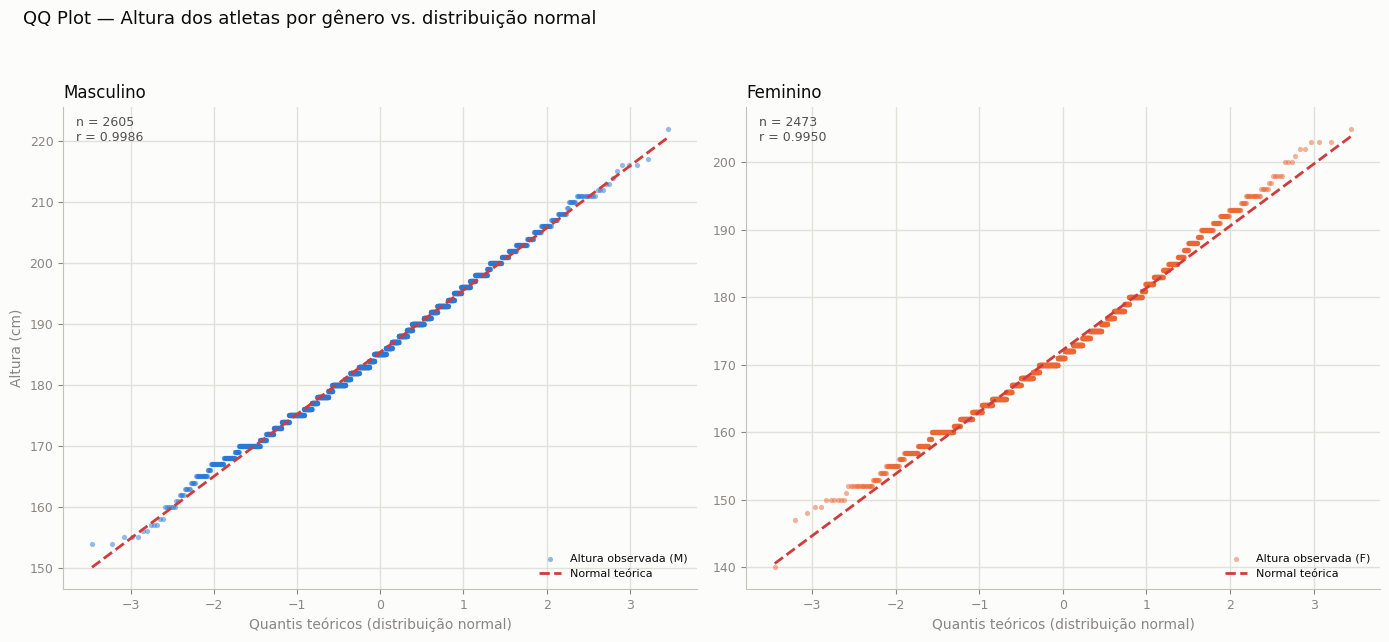

In [46]:
color_male = "#2a78d6"
color_female = "#eb6834"
color_reference = "#d03b3b"
color_primary = "#0b0b0b"
color_secondary = "#52514e"
color_muted = "#898781"
color_grid = "#e1e0d9"
color_baseline = "#c3c2b7"

def qq_subplot(ax, data, color, label):
    (osm, osr), (slope, intercept, r) = stats.probplot(data, dist="norm")
    ax.scatter(osm, osr, s=14, color=color, alpha=0.5, linewidths=0, label=label, zorder=2)
    line_x = [osm.min(), osm.max()]
    line_y = [slope * x + intercept for x in line_x]
    ax.plot(line_x, line_y, color=color_reference, linewidth=2, linestyle="--", label="Normal teórica", zorder=3)
    ax.text(0.02, 0.98, f"n = {len(data)}\nr = {r:.4f}", transform=ax.transAxes, ha="left", va="top", fontsize=9, color=color_secondary)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    ax.spines["left"].set_color(color_baseline)
    ax.spines["bottom"].set_color(color_baseline)
    ax.grid(True, color=color_grid, linewidth=1)
    ax.set_axisbelow(True)
    ax.tick_params(axis="both", colors=color_muted, labelsize=9)
    ax.legend(loc="lower right", frameon=False, labelcolor=color_primary, fontsize=8)

# altura == 0 continua sendo "sem registro", não altura zero — mesmo filtro de antes,
# agora separado por gênero pra ver se a distribuição normal se sustenta em cada grupo
height_male = athletes_df.loc[(athletes_df["gender"] == "Male") & (athletes_df["height"] > 0), "height"]
height_female = athletes_df.loc[(athletes_df["gender"] == "Female") & (athletes_df["height"] > 0), "height"]

fig, axes = plt.subplots(1, 2, figsize=(14, 6.5), facecolor="#fcfcfb")
for ax in axes:
    ax.set_facecolor("#fcfcfb")

qq_subplot(axes[0], height_male, color_male, "Altura observada (M)")
axes[0].set_xlabel("Quantis teóricos (distribuição normal)", color=color_muted, fontsize=10)
axes[0].set_ylabel("Altura (cm)", color=color_muted, fontsize=10)
axes[0].set_title("Masculino", color=color_primary, fontsize=12, loc="left")

qq_subplot(axes[1], height_female, color_female, "Altura observada (F)")
axes[1].set_xlabel("Quantis teóricos (distribuição normal)", color=color_muted, fontsize=10)
axes[1].set_title("Feminino", color=color_primary, fontsize=12, loc="left")

fig.suptitle("QQ Plot — Altura dos atletas por gênero vs. distribuição normal", color=color_primary, fontsize=13, x=0.02, ha="left")
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

159 atletas homens e 157 mulheres com peso registrado


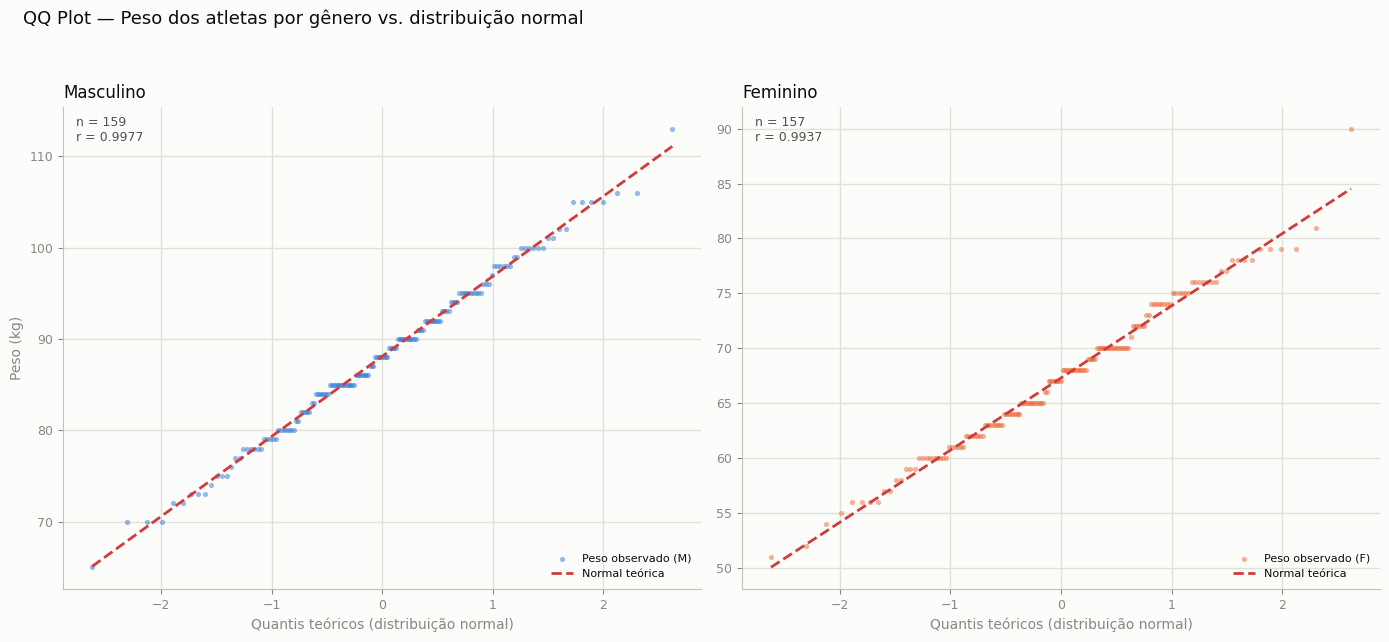

In [47]:
# peso == 0 também é "sem registro" — e é uma coluna bem mais esparsa que altura
# (só ~3% dos atletas têm peso registrado, contra ~46% de altura)
weight_male = athletes_df.loc[(athletes_df["gender"] == "Male") & (athletes_df["weight"] > 0), "weight"]
weight_female = athletes_df.loc[(athletes_df["gender"] == "Female") & (athletes_df["weight"] > 0), "weight"]
print(f"{len(weight_male)} atletas homens e {len(weight_female)} mulheres com peso registrado")

fig, axes = plt.subplots(1, 2, figsize=(14, 6.5), facecolor="#fcfcfb")
for ax in axes:
    ax.set_facecolor("#fcfcfb")

qq_subplot(axes[0], weight_male, color_male, "Peso observado (M)")
axes[0].set_xlabel("Quantis teóricos (distribuição normal)", color=color_muted, fontsize=10)
axes[0].set_ylabel("Peso (kg)", color=color_muted, fontsize=10)
axes[0].set_title("Masculino", color=color_primary, fontsize=12, loc="left")

qq_subplot(axes[1], weight_female, color_female, "Peso observado (F)")
axes[1].set_xlabel("Quantis teóricos (distribuição normal)", color=color_muted, fontsize=10)
axes[1].set_title("Feminino", color=color_primary, fontsize=12, loc="left")

fig.suptitle("QQ Plot — Peso dos atletas por gênero vs. distribuição normal", color=color_primary, fontsize=13, x=0.02, ha="left")
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

### Validando o modelo com dados que ele nunca viu

O R² de 0,7394 calculado na Seção 8 foi medido sobre os mesmos dados usados para treinar o modelo — uma medida naturalmente otimista. Aqui repetimos o mesmo modelo (PIB, PIB per capita, população) mas com uma divisão treino/teste (80/20): o modelo aprende só com 152 países e é avaliado nos 39 que nunca viu.

**R² treino = 0,7563 · R² teste = 0,5232.** A queda expressiva confirma que a métrica "cheia" superestimava a capacidade de generalização do modelo — com apenas 3 features e ~190 países, o modelo tem dificuldade em prever com precisão países fora da amostra de treino, ainda que a relação geral (mais riqueza → mais medalhas) continue válida.

In [48]:
from sklearn.model_selection import train_test_split

# Mesmo modelo de riqueza (PIB, PIB per capita, população) de antes, mas agora
# avaliado com train/test split — o R² anterior foi calculado em cima dos
# mesmos dados usados pra treinar, o que tende a ser otimista; aqui separamos
# 20% dos países para testar o quanto o modelo generaliza para dados que ele
# nunca viu
reg_df = countries_df[countries_df["athlete_count"].notna()].copy()
reg_df["Total"] = reg_df["Total"].fillna(0)

feature_cols = ["PIB", "PIB_per_capita", "populacao"]
reg_df = reg_df.dropna(subset=feature_cols)

X = reg_df[feature_cols]
y = reg_df["Total"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

model_tt = LinearRegression()
model_tt.fit(X_train, y_train)

r2_train = r2_score(y_train, model_tt.predict(X_train))
r2_test = r2_score(y_test, model_tt.predict(X_test))

print(f"{len(X_train)} países no treino, {len(X_test)} no teste")
print(f"R² treino = {r2_train:.4f}")
print(f"R² teste  = {r2_test:.4f}")

152 países no treino, 39 no teste
R² treino = 0.7563
R² teste  = 0.5232


## 10. Conclusões

- **Riqueza explica boa parte do desempenho olímpico, mas está longe de ser tudo.** O PIB total é o preditor mais forte entre os indicadores econômicos (R² = 0,74 no ajuste completo, 0,52 num teste honesto fora da amostra), mas países como Reino Unido, França, Austrália e Nova Zelândia superam muito o que sua riqueza sozinha previa — evidência de que investimento esportivo dedicado importa tanto quanto o tamanho da economia.
- **Tamanho da delegação é o fator mais correlacionado com medalhas (0,88)** — mais do que qualquer indicador puramente econômico. Mais atletas competindo significa mais chances de pódio.
- **População, isoladamente, não garante medalhas.** Nigéria, Indonésia e Paquistão — entre os países mais populosos do planeta — ficam abaixo da média de medalhas. A Índia é um caso à parte: supera a média em medalhas absolutas (6), mas tem de longe a pior eficiência população/medalha da base (242 milhões de habitantes por medalha) — um lembrete de que "abaixo da média" e "ineficiente" não são a mesma coisa.
- **PIB per capita e expectativa de vida caminham juntos**, e ambos se relacionam com mais medalhas: no bubble chart, os países no canto "rico e saudável" concentram as maiores bolhas.
- **A altura dos atletas segue de perto uma distribuição normal** (r ≈ 0,997 combinada; 0,999 no masculino e 0,995 no feminino quando separada por gênero) — um resultado esperado, já que características antropométricas em populações grandes tendem à normalidade pelo Teorema Central do Limite.
- **Qualidade dos dados importa tanto quanto a análise em si.** Boa parte do trabalho aqui foi justamente higienizar o cruzamento: tratar anos sem dado no World Bank, alinhar códigos de país entre dois padrões diferentes (COI vs. ISO-3166) e resolver colisões silenciosas de código (Bahrein/Brunei, Chile/Channel Islands) que, se ignoradas, teriam corrompido os resultados sem gerar nenhum erro visível.

---

**Autor:** João Pedro Dantas · IBMEC — 5º Período, Programação para Análise de Dados
**Dados:** [Paris 2024 Olympic Summer Games](https://www.kaggle.com/datasets/piterfm/paris-2024-olympic-summer-games) (Kaggle) · [World Development Indicators](https://data.worldbank.org/) (World Bank)